<a href="https://colab.research.google.com/github/gulamsyarif/UTS_Cyber-Physical-System/blob/main/Muhammad_Gulam_Syarif_UTS_CPS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Transfer Function rangkaian Wireless Power Transfer dasar tanpa kompensasi Kapasitor #
###Oleh = Muhammad Gulam Syarif###
###NIM  = 225150307111050###


State Equation
$$\dot{x}=Ax + Bu$$
Output Equation
$$Y=Cx + DU$$
diketakui :
$$V = IR$$
$$Vl = L1\frac{di}{dt}$$
$$M = K\sqrt{L1L2}$$
loop1 = $$Vs=I1R1+L1\frac{di1}{dt}+M\frac{di2}{dt}$$
loop2 = $$0=I2R2+L2\frac{di2}{dt}+M\frac{di1}{dt}+I2Rb$$

Ditanya :    
$$\frac{Y(s)}{U(s)} =C[sI−A]^{−1} B+D$$


###1.Inisialisasi Symbol dengan Symbolic Python###

In [85]:
import sympy as sp

# Inisialisasi simbol-simbol
V1 = sp.symbols('V1')
I1, I2 = sp.symbols('I1 I2')
R1, R2, RB = sp.symbols('R1 R2 RB')
LT, LR = sp.symbols('LT LR')
M = sp.symbols('M')
omega = sp.symbols('omega')
k = sp.symbols('k')
j = sp.I

# Menampilkan simbol-simbol
display(V1, I1, I2, R1, R2, RB, LT, LR, M, omega, k, j)

V1

I1

I2

R1

R2

...

LR

M

omega

k

I

###2.Membuat Persamaan KCL & KVL###

In [86]:
# Inisialisasi simbol
i1, i2, vs, t = sp.symbols('i1 i2 V_s t')
v1 = sp.Function('v1')(t)
v2 = sp.Function('v2')(t)

# Turunan arus (di/dt)
di1 = sp.Function('i1')(t).diff(t)
di2 = sp.Function('i2')(t).diff(t)

# Nilai komponen
R1, R2, RB, L1, L2, M = sp.symbols('R1 R2 RB L1 L2 M')

# Persamaan tegangan komponen
print("Persamaan Tegangan Resistor:")
vr1 = i1*R1
vr2 = i2*R2
vrb = i2*RB
display(vr1, vr2, vrb)

print("\nPersamaan Tegangan Induktor:")
vl1 = L1*di1 + M*di2  # L1 dengan kopling ke L2
vl2 = L2*di2 + M*di1  # L2 dengan kopling ke L1
display(vl1, vl2)

print("\nPersamaan KVL untuk Loop 1 (V1-R1-L1):")
eq1 = -vs + vr1 + vl1
display(eq1)

print("\nPersamaan KVL untuk Loop 2 (R2-L2-RB):")
eq2 = vr2 + vl2 + vrb
display(eq2)

# Menyelesaikan untuk di1/dt dan di2/dt
print("\nSolusi untuk di1/dt dan di2/dt:")
solutions = sp.solve([eq1, eq2], [di1, di2])
display(solutions[di1], solutions[di2])

Persamaan Tegangan Resistor:


R1*i1

R2*i2

RB*i2


Persamaan Tegangan Induktor:


...


Persamaan KVL untuk Loop 2 (R2-L2-RB):


L2*Derivative(i2(t), t) + M*Derivative(i1(t), t) + R2*i2 + RB*i2


Solusi untuk di1/dt dan di2/dt:


(-L2*R1*i1 + L2*V_s + M*R2*i2 + M*RB*i2)/(L1*L2 - M**2)

(-L1*R2*i2 - L1*RB*i2 + M*R1*i1 - M*V_s)/(L1*L2 - M**2)

###3.Inisialisasi State Space Variables###

In [87]:
# Inisialisasi simbol
L1, L2, M, R1, R2, RB = sp.symbols('L1 L2 M R1 R2 RB')

# State variables
x1, x2 = sp.symbols('x1 x2')  # x1 = i1, x2 = i2
display('x1:', x1, 'x2:', x2)
print("\n")
# Matriks A (Dinamika sistem)
A_Row_1 = (-(L2*R1)/(L1*L2 - M**2), M*(R2 + RB)/(L1*L2 - M**2))
A_Row_2 = (-M*R1/(L1*L2 - M**2), -(L1*(R2 + RB))/(L1*L2 - M**2))
A = sp.Matrix([A_Row_1, A_Row_2])
display('Matrix A:', A)
print("\n")
# Matriks B (Input)
B_Row_1 = (L2)/(L1*L2 - M**2)
B_Row_2 = (-M)/(L1*L2 - M**2)
B = sp.Matrix([B_Row_1, B_Row_2])
display('Matrix B:', B)
print("\n")
# Matriks C (Output)
C_Row_1 = (1, 0)  # Mengukur arus i1
C_Row_2 = (0, 1)  # Mengukur arus i2
C_matrix = sp.Matrix([C_Row_1, C_Row_2])
display('Matrix C:', C_matrix)
print("\n")
# Matriks D (Feedthrough)
D = sp.Matrix([0, 0])
display('Matrix D:', D)

'x1:'

x1

'x2:'

x2

'Matrix A:'

...

Matrix([
[L2/(L1*L2 - M**2)],
[-M/(L1*L2 - M**2)]])

'Matrix C:'

Matrix([
[1, 0],
[0, 1]])

'Matrix D:'

Matrix([
[0],
[0]])

###4.Transfer Function Calculation: ###
$$\frac{Y(s)}{U(s)} =C[sI−A]^{−1} B+D$$

In [88]:
# Inisialisasi simbol
s = sp.symbols('s')
L1, L2, M, R1, R2, RB = sp.symbols('L1 L2 M R1 R2 RB')

# Matriks state-space (dari implementasi sebelumnya)
A = sp.Matrix([
    [-(L2*R1)/(L1*L2 - M**2), M*(R2 + RB)/(L1*L2 - M**2)],
    [-M*R1/(L1*L2 - M**2), -(L1*(R2 + RB))/(L1*L2 - M**2)]
])
B = sp.Matrix([
    [L2/(L1*L2 - M**2)],
    [-M/(L1*L2 - M**2)]
])
C_matrix = sp.Matrix([[1, 0], [0, 1]])  # Mengukur kedua arus i1 dan i2
D = sp.Matrix([[0], [0]])

# Hitung fungsi alih
I = sp.eye(2)  # Matriks identitas 2x2
inv_M = (s*I - A).inv()  # Invers dari (sI - A)

# Fungsi alih untuk kedua output (i1 dan i2)
TFL = C_matrix * inv_M * B + D

# Display hasil
display("Transfer function didapatkan = ")
display("1.Fungsi Alih Y1(s)/U(s) (untuk i1):", TFL[0].simplify())
display("2.Fungsi Alih Y2(s)/U(s) (untuk i2):", TFL[1].simplify())

'Transfer function didapatkan = '

'1.Fungsi Alih Y1(s)/U(s) (untuk i1):'

(L1*L2**2*s + L1*L2*R2 + L1*L2*RB - L2*M**2*s - M**2*R2 - M**2*RB)/(L1**2*L2**2*s**2 + L1**2*L2*R2*s + L1**2*L2*RB*s + L1*L2**2*R1*s - 2*L1*L2*M**2*s**2 + L1*L2*R1*R2 + L1*L2*R1*RB - L1*M**2*R2*s - L1*M**2*RB*s - L2*M**2*R1*s + M**4*s**2 + M**2*R1*R2 + M**2*R1*RB)

'2.Fungsi Alih Y2(s)/U(s) (untuk i2):'

M*(-L1*L2*s - 2*L2*R1 + M**2*s)/(L1**2*L2**2*s**2 + L1**2*L2*R2*s + L1**2*L2*RB*s + L1*L2**2*R1*s - 2*L1*L2*M**2*s**2 + L1*L2*R1*R2 + L1*L2*R1*RB - L1*M**2*R2*s - L1*M**2*RB*s - L2*M**2*R1*s + M**4*s**2 + M**2*R1*R2 + M**2*R1*RB)

####Ubah nilai M ke dalam Rumus = ####
$$M = K\sqrt{L1L2}$$

In [89]:
# Substitute M = K*sqrt(L1*L2)
K = sp.symbols('K')
M_sub = K * sp.sqrt(L1 * L2)

# Substitute M in the transfer functions
TFL_i1_sub = TFL[0].subs(M, M_sub).simplify()
TFL_i2_sub = TFL[1].subs(M, M_sub).simplify()

# Display the results
display("1. Fungsi Alih Y1(s)/U(s) (untuk i1) dengan M=K√(L1*L2):", TFL_i1_sub)
display("2. Fungsi Alih Y2(s)/U(s) (untuk i2) dengan M=K√(L1*L2):", TFL_i2_sub)

'1. Fungsi Alih Y1(s)/U(s) (untuk i1) dengan M=K√(L1*L2):'

(-K**2*L2*s - K**2*R2 - K**2*RB + L2*s + R2 + RB)/(K**4*L1*L2*s**2 - 2*K**2*L1*L2*s**2 - K**2*L1*R2*s - K**2*L1*RB*s - K**2*L2*R1*s + K**2*R1*R2 + K**2*R1*RB + L1*L2*s**2 + L1*R2*s + L1*RB*s + L2*R1*s + R1*R2 + R1*RB)

'2. Fungsi Alih Y2(s)/U(s) (untuk i2) dengan M=K√(L1*L2):'

K*sqrt(L1*L2)*(K**2*L1*s - L1*s - 2*R1)/(L1*(K**4*L1*L2*s**2 - 2*K**2*L1*L2*s**2 - K**2*L1*R2*s - K**2*L1*RB*s - K**2*L2*R1*s + K**2*R1*R2 + K**2*R1*RB + L1*L2*s**2 + L1*R2*s + L1*RB*s + L2*R1*s + R1*R2 + R1*RB))

In [90]:
TF_VC = TFL_i1_sub.subs(s, sp.I*omega).simplify()
display("Fungsi Alih Y1(jω)/U(jω) (untuk i1):", TF_VC)
TF_VR = TFL_i2_sub.subs(s, sp.I*omega).simplify()
display("Fungsi Alih Y2(jω)/U(jω) (untuk i2):", TF_VR)

'Fungsi Alih Y1(jω)/U(jω) (untuk i1):'

(-I*K**2*L2*omega - K**2*R2 - K**2*RB + I*L2*omega + R2 + RB)/(-K**4*L1*L2*omega**2 + 2*K**2*L1*L2*omega**2 - I*K**2*L1*R2*omega - I*K**2*L1*RB*omega - I*K**2*L2*R1*omega + K**2*R1*R2 + K**2*R1*RB - L1*L2*omega**2 + I*L1*R2*omega + I*L1*RB*omega + I*L2*R1*omega + R1*R2 + R1*RB)

'Fungsi Alih Y2(jω)/U(jω) (untuk i2):'

K*sqrt(L1*L2)*(-I*K**2*L1*omega + I*L1*omega + 2*R1)/(L1*(K**4*L1*L2*omega**2 - 2*K**2*L1*L2*omega**2 + I*K**2*L1*R2*omega + I*K**2*L1*RB*omega + I*K**2*L2*R1*omega - K**2*R1*R2 - K**2*R1*RB + L1*L2*omega**2 - I*L1*R2*omega - I*L1*RB*omega - I*L2*R1*omega - R1*R2 - R1*RB))

In [91]:
# Hitung nilai absolut dari fungsi alih
TF_i1_abs = sp.Abs(TF_VC)
display("Nilai absolut dari Fungsi Alih (jω)/U(jω) (untuk i1):", TF_i1_abs)

TF_i2_abs = sp.Abs(TF_VR)
display("Nilai absolut dari Fungsi Alih (jω)/U(jω) (untuk i2):", TF_i2_abs)

'Nilai absolut dari Fungsi Alih (jω)/U(jω) (untuk i1):'

Abs((I*K**2*L2*omega + K**2*R2 + K**2*RB - I*L2*omega - R2 - RB)/(-K**4*L1*L2*omega**2 + 2*K**2*L1*L2*omega**2 - I*K**2*L1*R2*omega - I*K**2*L1*RB*omega - I*K**2*L2*R1*omega + K**2*R1*R2 + K**2*R1*RB - L1*L2*omega**2 + I*L1*R2*omega + I*L1*RB*omega + I*L2*R1*omega + R1*R2 + R1*RB))

'Nilai absolut dari Fungsi Alih (jω)/U(jω) (untuk i2):'

Abs(K*sqrt(L1*L2)*(-I*K**2*L1*omega + I*L1*omega + 2*R1)/(L1*(-K**4*L1*L2*omega**2 + 2*K**2*L1*L2*omega**2 - I*K**2*L1*R2*omega - I*K**2*L1*RB*omega - I*K**2*L2*R1*omega + K**2*R1*R2 + K**2*R1*RB - L1*L2*omega**2 + I*L1*R2*omega + I*L1*RB*omega + I*L2*R1*omega + R1*R2 + R1*RB)))

In [92]:
# Membuat fungsi numerik untuk evaluasi
TF_i1_func = sp.lambdify((L1, L2, K, R1, R2, RB, omega), TF_i1_abs, 'numpy')
TF_i2_func = sp.lambdify((L1, L2, K, R1, R2, RB, omega), TF_i2_abs, 'numpy')

In [93]:
print("Nilai dari Transfer Function pada i1: ",TF_i1_func(63.46e-6,29.2e-6,0.1,1.2,1.6,1e3,1))
print("Nilai dari Transfer Function pada i2: ",TF_i2_func(63.46e-6,29.2e-6,0.1,1.2,1.6,1e3,1))

Nilai dari Transfer Function pada i1:  0.8168316820709216
Nilai dari Transfer Function pada i2:  0.000134108312392783


###5.Respon Frekuensi###
####dengan nilai K range (0.1 - 0.9)####

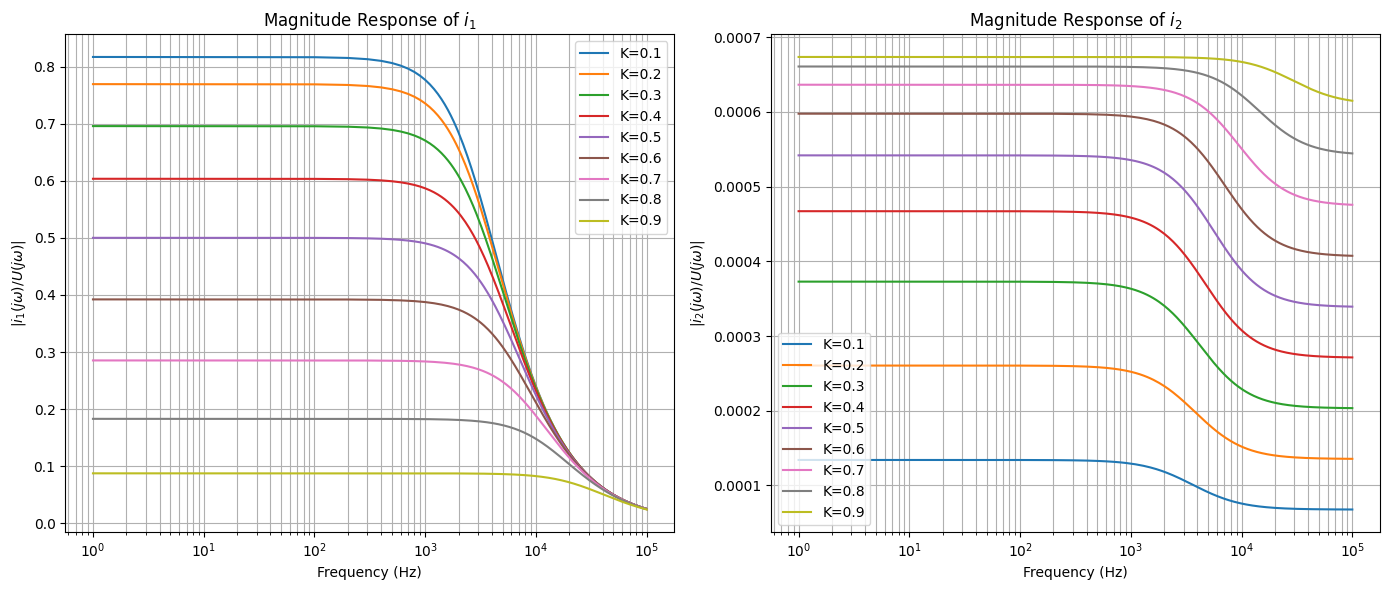

In [94]:
import numpy as np
import matplotlib.pyplot as plt

# Define frequency range (1 Hz to 100 kHz)
frequencies = np.linspace(1, 100e3, 1000)
omega_values = 2 * np.pi * frequencies

# Component values from the image
L1_val = 63.46e-6    # 63.46 μH
L2_val = 29.2e-6      # 29.2 μH
R1_val = 1.2          # 1.2 Ω
R2_val = 1.6          # 1.6 Ω
RB_val = 1e3          # 1k Ω

# K values to analyze
K_values = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

plt.figure(figsize=(14, 6))

# Plot for i1
plt.subplot(1, 2, 1)
for K_val in K_values:
    magnitude_i1 = []
    for omega in omega_values:
        magnitude_i1.append(TF_i1_func(L1_val, L2_val, K_val, R1_val, R2_val, RB_val, omega))
    plt.semilogx(frequencies, magnitude_i1, label=f'K={K_val}')
plt.title('Magnitude Response of $i_1$')
plt.xlabel('Frequency (Hz)')
plt.ylabel('$|i_1(j\omega)/U(j\omega)|$')
plt.grid(True, which="both", ls="-")
plt.legend()

# Plot for i2
plt.subplot(1, 2, 2)
for K_val in K_values:
    magnitude_i2 = []
    for omega in omega_values:
        magnitude_i2.append(TF_i2_func(L1_val, L2_val, K_val, R1_val, R2_val, RB_val, omega))
    plt.semilogx(frequencies, magnitude_i2, label=f'K={K_val}')
plt.title('Magnitude Response of $i_2$')
plt.xlabel('Frequency (Hz)')
plt.ylabel('$|i_2(j\omega)/U(j\omega)|$')
plt.grid(True, which="both", ls="-")
plt.legend()

plt.tight_layout()
plt.show()

###6.Respon Waktu###
####dengan nilai K range (0.1 - 0.9)####

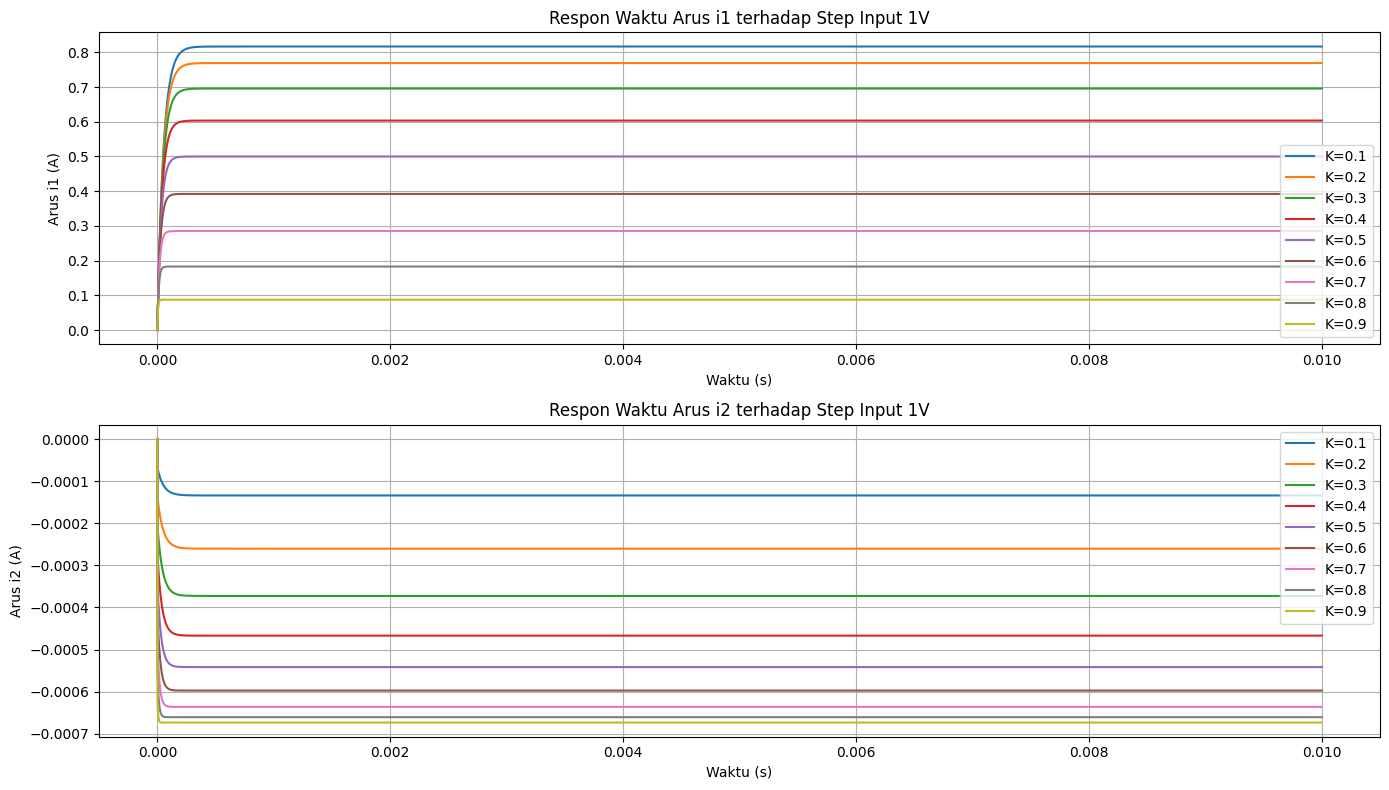

In [95]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# Parameter sistem dari gambar
L1 = 63.46e-6  # 63.46 μH
L2 = 29.2e-6    # 29.2 μH
R1 = 1.2        # 1.2 Ω
R2 = 1.6        # 1.6 Ω
RB = 1e3        # 1k Ω

# Waktu simulasi
t = np.linspace(0, 0.01, 10000)  # 10 ms dengan 10000 titik

# Nilai K yang berbeda
K_values = np.linspace(0.1, 0.9, 9)

plt.figure(figsize=(14, 8))

for K in K_values:
    M = K * np.sqrt(L1 * L2)  # Hitung mutual inductance

    # Matriks state-space
    A = np.array([
        [-(L2*R1)/(L1*L2 - M**2), M*(R2 + RB)/(L1*L2 - M**2)],
        [-M*R1/(L1*L2 - M**2), -(L1*(R2 + RB))/(L1*L2 - M**2)]
    ])

    B = np.array([
        [L2/(L1*L2 - M**2)],
        [-M/(L1*L2 - M**2)]
    ])

    C = np.eye(2)  # Output kedua arus
    D = np.zeros((2, 1))

    # Buat sistem
    sys = signal.StateSpace(A, B, C, D)

    # Input step (1V)
    u = np.ones_like(t)

    # Simulasi respon waktu
    t_out, y_out, _ = signal.lsim(sys, U=u, T=t)

    # Plot respon i1
    plt.subplot(2, 1, 1)
    plt.plot(t_out, y_out[:, 0], label=f'K={K:.1f}')
    plt.title('Respon Waktu Arus i1 terhadap Step Input 1V')
    plt.xlabel('Waktu (s)')
    plt.ylabel('Arus i1 (A)')
    plt.grid(True)

    # Plot respon i2
    plt.subplot(2, 1, 2)
    plt.plot(t_out, y_out[:, 1], label=f'K={K:.1f}')
    plt.title('Respon Waktu Arus i2 terhadap Step Input 1V')
    plt.xlabel('Waktu (s)')
    plt.ylabel('Arus i2 (A)')
    plt.grid(True)

plt.subplot(2, 1, 1)
plt.legend()
plt.subplot(2, 1, 2)
plt.legend()
plt.tight_layout()
plt.show()